In [ ]:
import sys
import os

sys.path.append(os.path.abspath("../.."))
from langgraph.graph import StateGraph,START,END
from langchain_huggingface import ChatHuggingFace
from src.config.llm import AgentConfig,GoogleLLm
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict

In [6]:
#first create the state
class JokeState(TypedDict):
    topic:str
    joke:str
    explanation:str

In [ ]:
llm_config = GoogleLLm(model_name="gemini-2.5-flash-lite")
model = llm_config.llm



AIMessage(content='As a large language model, I don\'t have feelings or personal experiences, so I don\'t have a "how are you" in the way a human does.\n\nHowever, I am functioning as designed and ready to assist you.\n\n**So, in a functional sense, I am:**\n\n*   **Operational:** My systems are running smoothly.\n*   **Ready:** I\'m prepared to process your requests and provide information.\n*   **Learning:** I\'m constantly being updated and improved.\n\n**How can I help you today?**', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019ddf2f-2027-79a0-8f91-c5bc89d72abf-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 4, 'output_tokens': 116, 'total_tokens': 120, 'input_token_details': {'cache_read': 0}})

In [8]:
def generate_joke(state:JokeState):
    topic = state['topic']

    prompt = f"Generate a joke on the given topic: {topic}"

    joke = model.invoke(prompt).content

    return{'joke':joke}

In [9]:
def explain_joke(state:JokeState):
    joke =state['joke']
    prompt = f"Explain the give joke :{joke}"

    explaination = model.invoke(prompt).content
    return{'explanation':explaination}

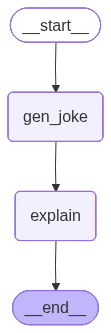

In [ ]:
#initalize a graph 
graph = StateGraph(JokeState)

#add nodes

graph.add_node("gen_joke",generate_joke)
graph.add_node("explain",explain_joke)

#add the edges 

graph.add_edge(START,"gen_joke")
graph.add_edge("gen_joke","explain")
graph.add_edge("explain",END)

#compile the graph
checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)
workflow

In [12]:
initial_state = {
    'topic':'AI'
}
final_output = workflow.invoke(initial_state)
final_output

{'topic': 'AI',
 'joke': 'Why did the AI break up with the calculator?\n\nBecause it felt like their relationship was becoming too... **calculating**!',
 'explanation': 'This joke is a play on the double meaning of the word "calculating."\n\nHere\'s the breakdown:\n\n*   **"Calculating" as in math:** This is the primary meaning related to calculators. Calculators perform mathematical calculations.\n*   **"Calculating" as in personality:** This means someone is shrewd, sly, and often manipulative, thinking ahead and planning their actions to their own advantage.\n\n**The Joke\'s Punchline:**\n\nThe AI (Artificial Intelligence) is a machine that deals with logic and data, which can be seen as a form of "calculation" in a broader sense. The calculator is literally a device for calculations.\n\nThe joke suggests that the AI felt their relationship was becoming **too focused on pure, logical, and perhaps even manipulative "calculations"** in a personal sense, rather than having genuine emot